# Capital Bikeshare — Trực quan hóa

+ Dữ liệu: `dataclean/capitalbike_cleaned.parquet`
+ Hệ thống: **Capital Bikeshare**
+ Kỳ phân tích: 04/2025–04/2026
+ Chạy **Run All** sau khi đã clean (`scripts/run_clean_all.py`)


### Thiết lập môi trường

+ Thêm thư mục gốc dự án vào `sys.path`
+ Import và reload `visualize_plots`, `station_maps` từ `src/`
+ Gán `DATA_PATH` trỏ tới file parquet đã clean
+ Báo lỗi nếu chưa chạy `scripts/run_clean_all.py`


In [187]:
import importlib
import os
import sys
from pathlib import Path

current_dir = os.getcwd()
if current_dir.endswith(("notebooks", "1.statistic", "2.visualize")):
    project_root = os.path.abspath(os.path.join(current_dir, ".."))
else:
    project_root = current_dir

if project_root not in sys.path:
    sys.path.insert(0, project_root)

import src.visualize_plots as visualize_plots
import src.station_maps as station_maps
importlib.reload(visualize_plots)
importlib.reload(station_maps)

from src.visualize_plots import (
    plot_user_type_pie,
    plot_bike_type_pie_by_user,
    plot_duration_by_bike_type,
    plot_duration_by_bike_type_pct,
    plot_duration_box_by_bike,
    plot_hourly_demand_by_bike_type_count,
    plot_hourly_demand_by_bike_type,
    plot_duration_by_user_group,
    plot_duration_by_user_group_pct,
    plot_duration_box_by_user,
    plot_hourly_demand_by_user_count,
    plot_hourly_demand_by_user,
    plot_monthly_demand_by_user_count,
    plot_monthly_demand_by_user,
    plot_weekday_demand_by_bike_type,
    plot_weekday_demand_by_user,
    plot_weekly_usage_heatmap,
    plot_weekly_usage_heatmap_by_bike_type,
    plot_weekly_usage_heatmap_user_bike_grid,
    plot_monthly_usage_heatmaps,
    plot_monthly_usage_heatmaps_by_bike_type,
    plot_monthly_usage_heatmaps_member_by_bike,
    plot_monthly_usage_heatmaps_casual_by_bike,
)
from src.station_maps import plot_station_map

CLEAN_FILE = "capitalbike_cleaned.parquet"
SYSTEM_NAME = "Capital Bikeshare"
DATA_PATH = Path(project_root) / "dataclean" / CLEAN_FILE

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Chưa có {DATA_PATH}. Chạy scripts/run_clean_all.py trước.")


## Khối 0 · Tổng quan cơ cấu

+ Hai biểu đồ tròn mở đầu notebook
+ Nắm tỷ lệ người dùng và loại xe trước khi đi sâu


### 1. Tỷ lệ member vs casual

+ Biểu đồ tròn toàn bộ chuyến trong kỳ
+ So sánh member (thuê bao) vs casual (vé lẻ / ngày)


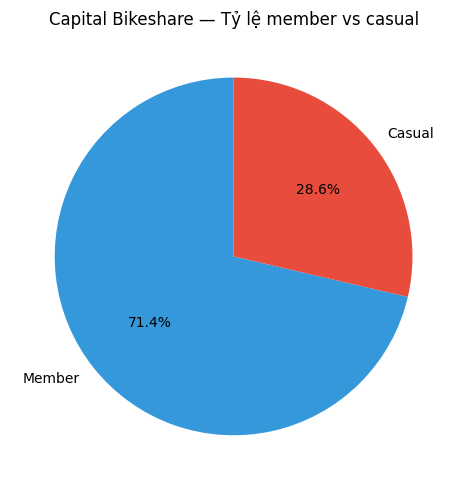

In [188]:
plot_user_type_pie(DATA_PATH, SYSTEM_NAME)


### 2. Tỷ lệ loại xe theo nhóm người dùng

+ Hai pie nhỏ: member và casual
+ Mỗi pie tách classic bike vs e-bike


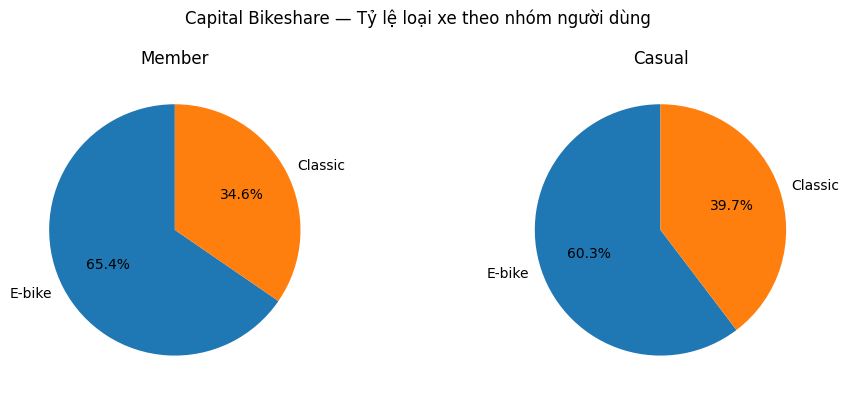

In [189]:
plot_bike_type_pie_by_user(DATA_PATH, SYSTEM_NAME)


## Khối A · Classic vs e-bike

+ Phân tích thời lượng, giờ cao điểm theo loại xe
+ Gồm histogram, box plot và biểu đồ theo giờ


### 3. Thời lượng — số chuyến (0–120 phút)

+ Histogram chồng theo số chuyến thực tế
+ Trục X: phút đi; hai màu classic vs e-bike


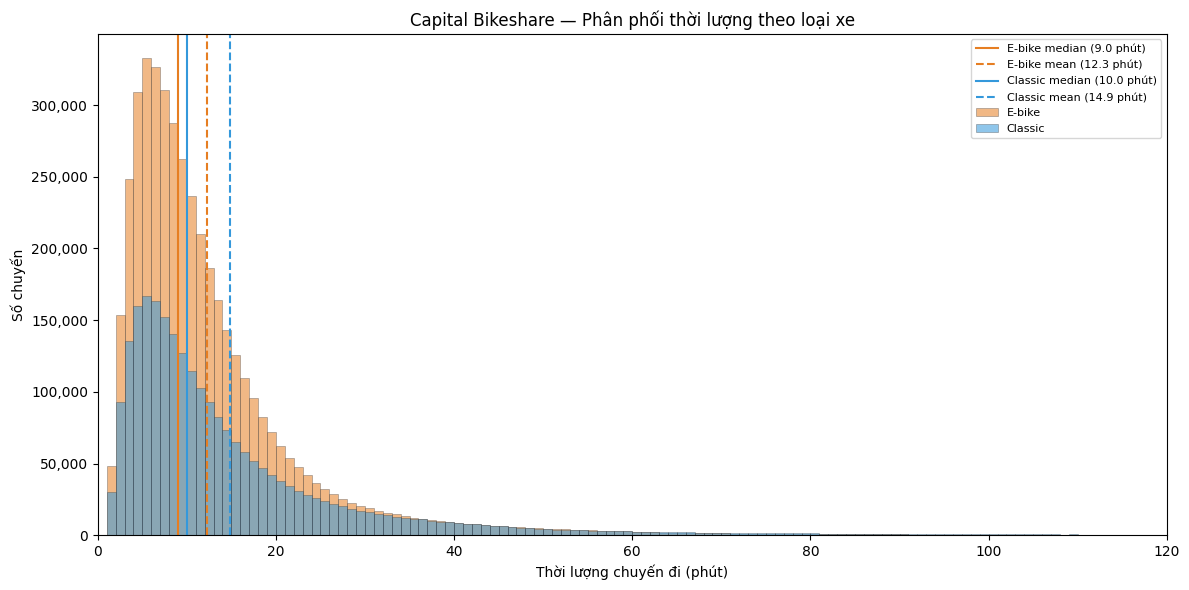

In [190]:
plot_duration_by_bike_type(DATA_PATH, SYSTEM_NAME)


### 4. Thời lượng — % trong từng loại xe

+ Mỗi loại xe chuẩn hóa 100% riêng
+ So sánh hình dạng phân phối, không bị lệch bởi quy mô


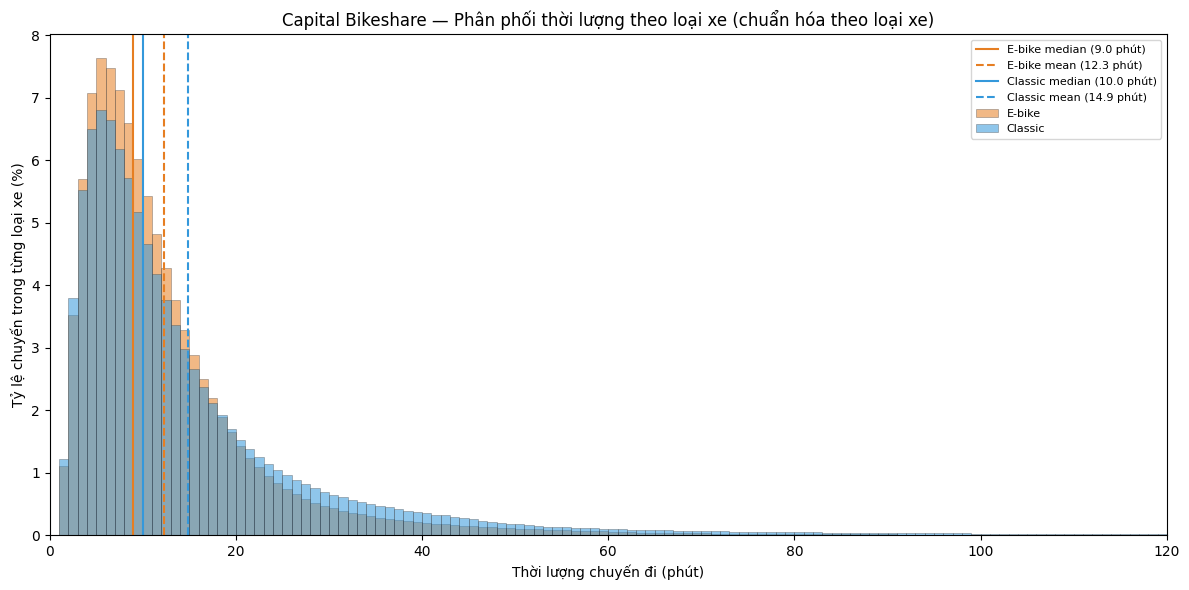

In [191]:
plot_duration_by_bike_type_pct(DATA_PATH, SYSTEM_NAME)


### Box plot — classic vs e-bike (0–120 phút)

+ Tóm tắt Q1, median, Q3 và whisker Tukey
+ Bổ sung cho histogram — thấy outlier và độ tập trung


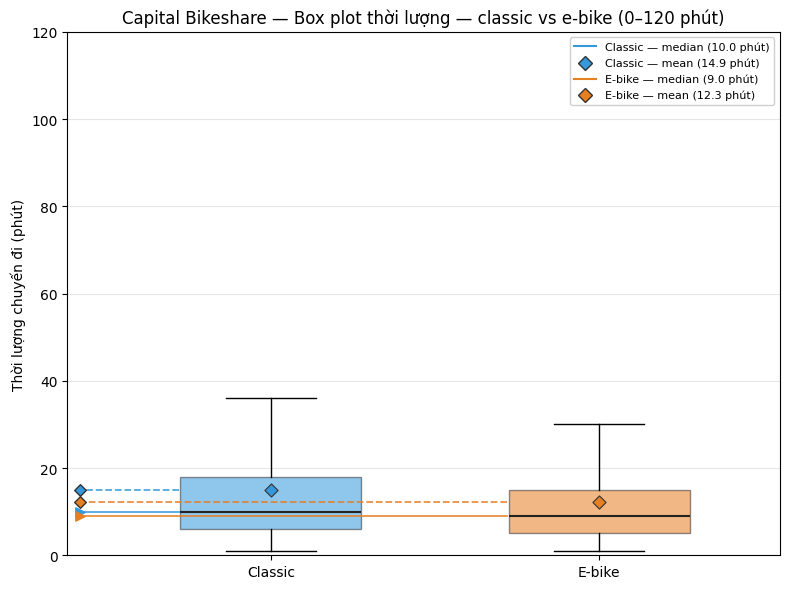

In [192]:
plot_duration_box_by_bike(DATA_PATH, SYSTEM_NAME)


### 5. Nhu cầu theo giờ — số chuyến

+ Trục X: giờ bắt đầu chuyến (0–23)
+ Vùng vàng/cam đánh dấu cao điểm 7–9h và 16–18h


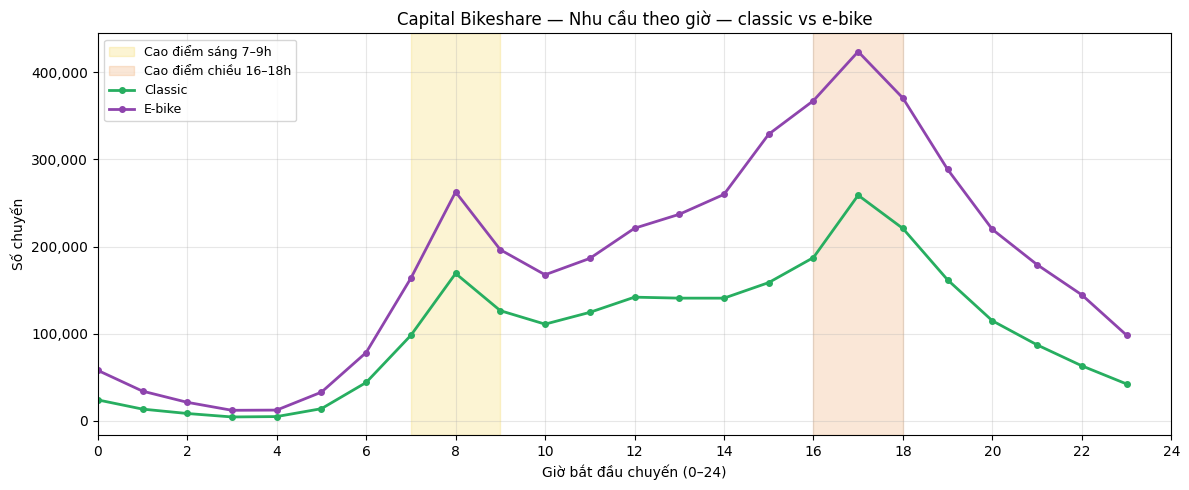

In [193]:
plot_hourly_demand_by_bike_type_count(DATA_PATH, SYSTEM_NAME)


### 6. Nhu cầu theo giờ — % trong từng loại xe

+ Mỗi loại xe chuẩn hóa 100% theo 24 giờ
+ So sánh pattern giờ cao điểm giữa classic và e-bike


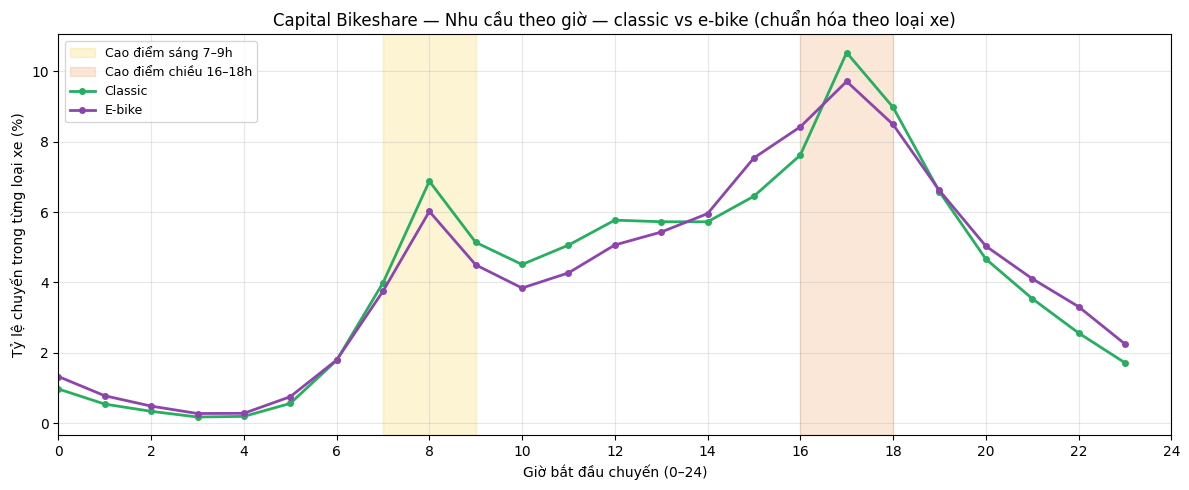

In [194]:
plot_hourly_demand_by_bike_type(DATA_PATH, SYSTEM_NAME)


## Khối B · Member vs casual

+ Phân tích thời lượng, giờ và tháng theo nhóm người dùng
+ Member thường đi ngắn hơn, đều hơn; casual dài hơn, cuối tuần mạnh hơn


### 7. Thời lượng — số chuyến (0–120 phút)

+ Histogram chồng theo số chuyến thực tế
+ Hai màu: member vs casual


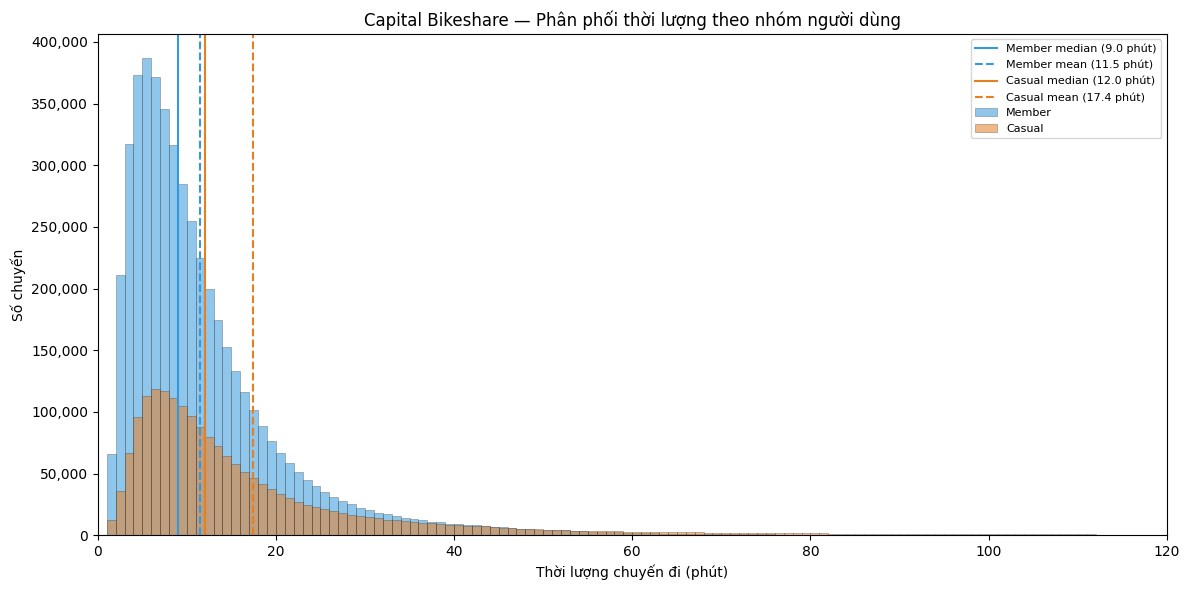

In [195]:
plot_duration_by_user_group(DATA_PATH, SYSTEM_NAME)


### 8. Thời lượng — % trong từng nhóm

+ Mỗi nhóm chuẩn hóa 100% riêng
+ So sánh hình dạng phân phối thời lượng


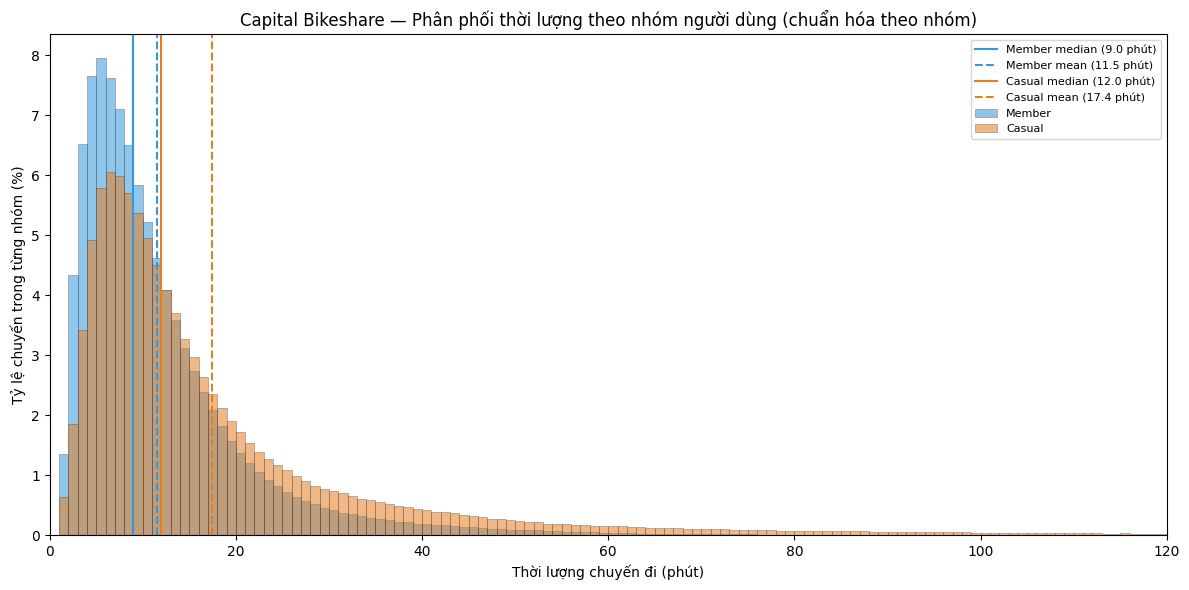

In [196]:
plot_duration_by_user_group_pct(DATA_PATH, SYSTEM_NAME)


### Box plot — member vs casual (0–120 phút)

+ Tóm tắt Q1, median, Q3 và whisker Tukey
+ Thấy casual có đuôi dài hơn (chuyến dài / du lịch)


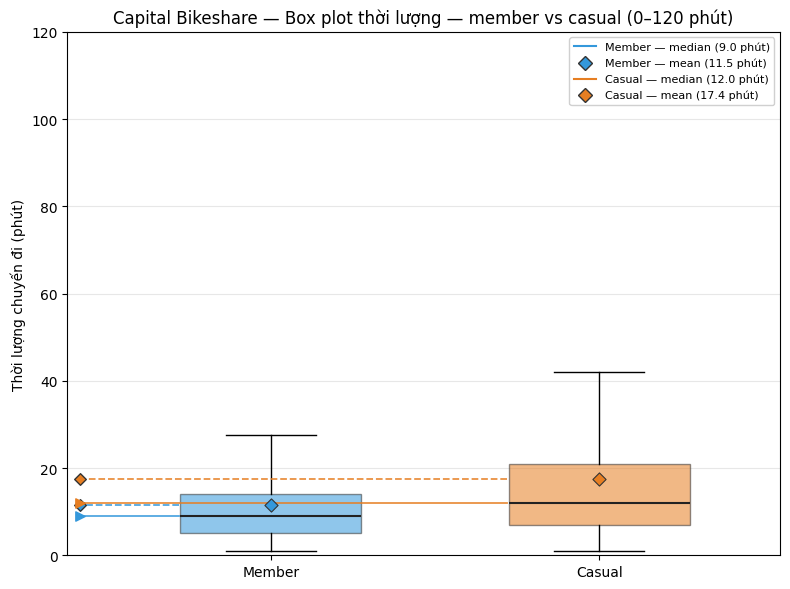

In [197]:
plot_duration_box_by_user(DATA_PATH, SYSTEM_NAME)


### 9. Nhu cầu theo giờ — số chuyến

+ Trục X: giờ bắt đầu (0–23)
+ Member đỉnh sáng/tối ngày thường; casual phẳng hơn, cuối tuần cao


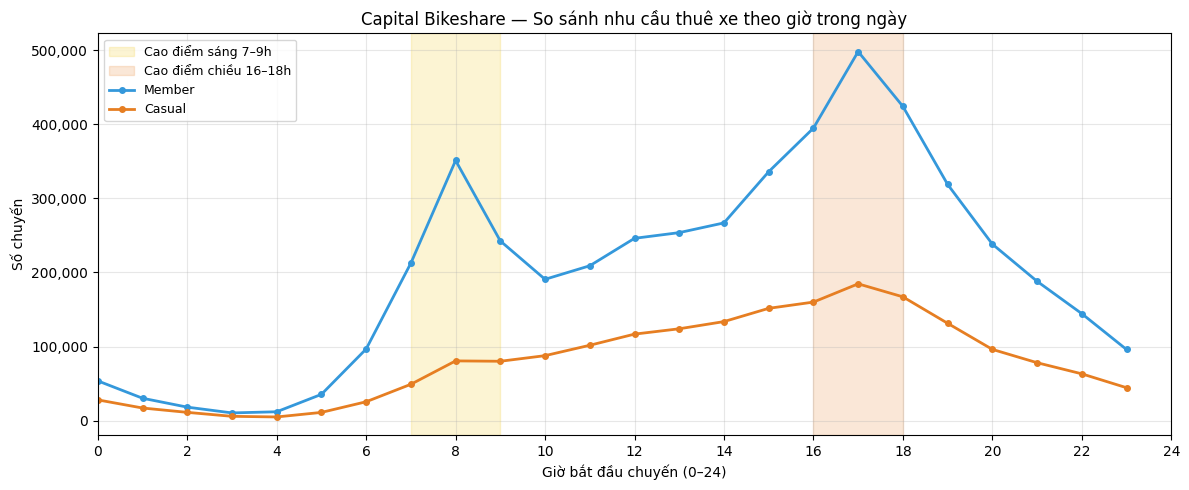

In [198]:
plot_hourly_demand_by_user_count(DATA_PATH, SYSTEM_NAME)


### 10. Nhu cầu theo giờ — % trong từng nhóm

+ Mỗi nhóm chuẩn hóa 100% theo 24 giờ
+ So sánh pattern giờ không bị lệch bởi số lượng member lớn hơn


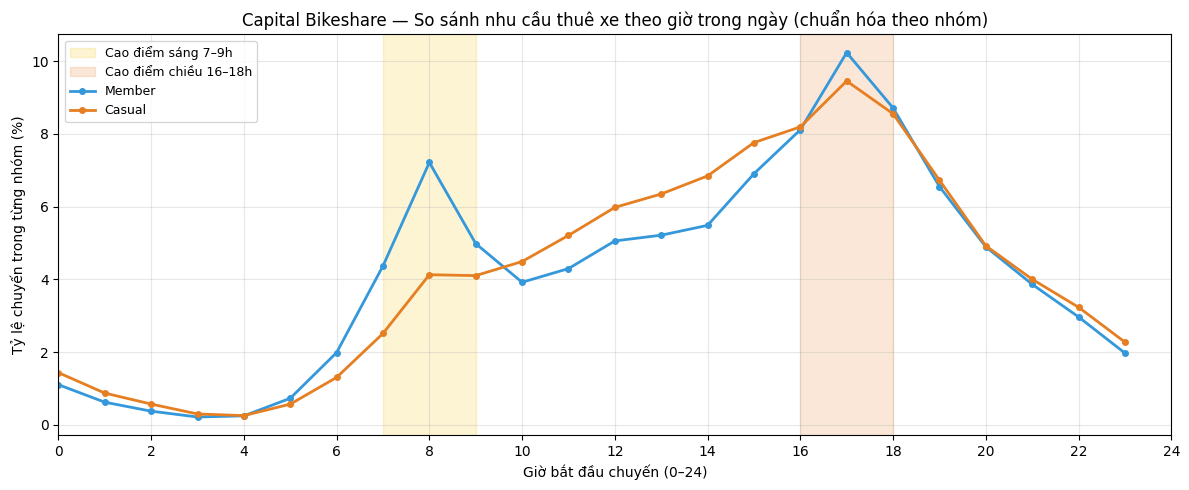

In [199]:
plot_hourly_demand_by_user(DATA_PATH, SYSTEM_NAME)


### 11. Nhu cầu theo tháng — số chuyến

+ Kỳ 04/2025–04/2026 (13 tháng)
+ Nền cam: hè (6–8); nền xanh nhạt: đông (12–2)


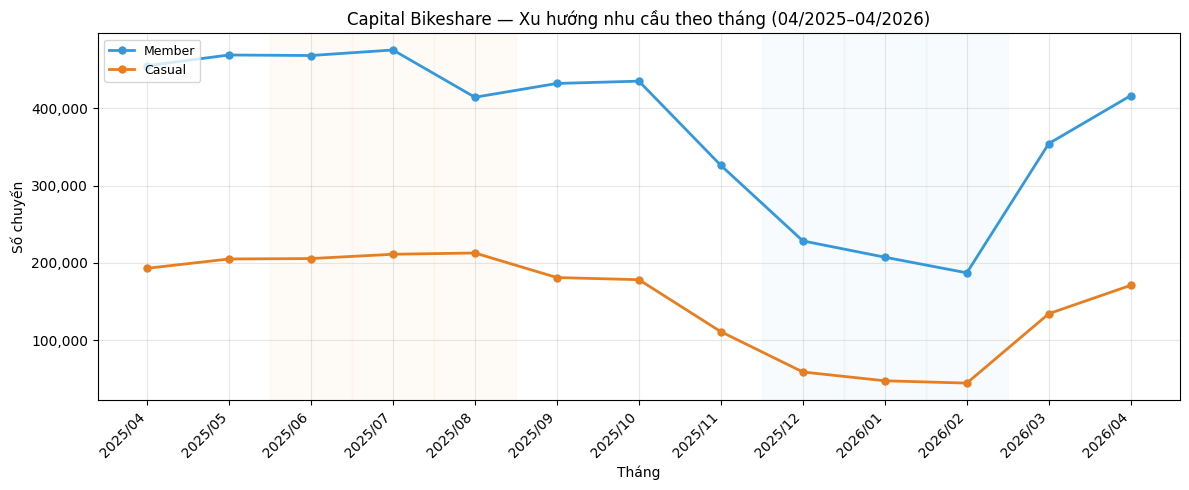

In [200]:
plot_monthly_demand_by_user_count(DATA_PATH, SYSTEM_NAME)


### 12. Nhu cầu theo tháng — % trong từng nhóm

+ Mỗi nhóm chuẩn hóa 100% theo 13 tháng
+ Thấy mùa vụ tương đối, không bị scale bởi tổng chuyến


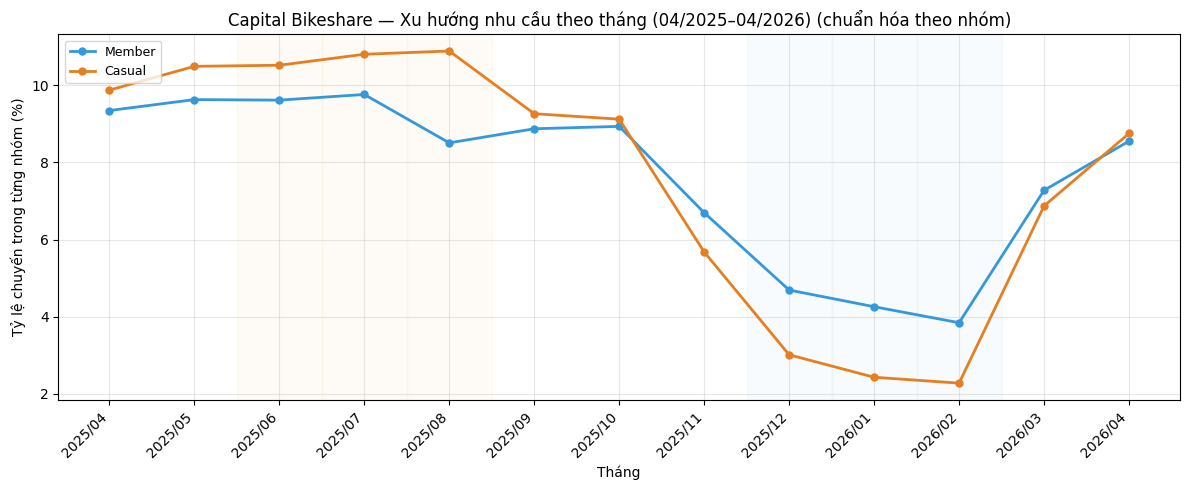

In [201]:
plot_monthly_demand_by_user(DATA_PATH, SYSTEM_NAME)


## Khối C · Ngày trong tuần (T2–CN)

+ Hai line chart 7 ngày
+ Vùng tím nhạt: cuối tuần (T7–CN)


### 13. Classic vs e-bike — số chuyến

+ Line chart 7 ngày theo loại xe
+ Chỉ số chuyến thực tế, không chuẩn hóa %


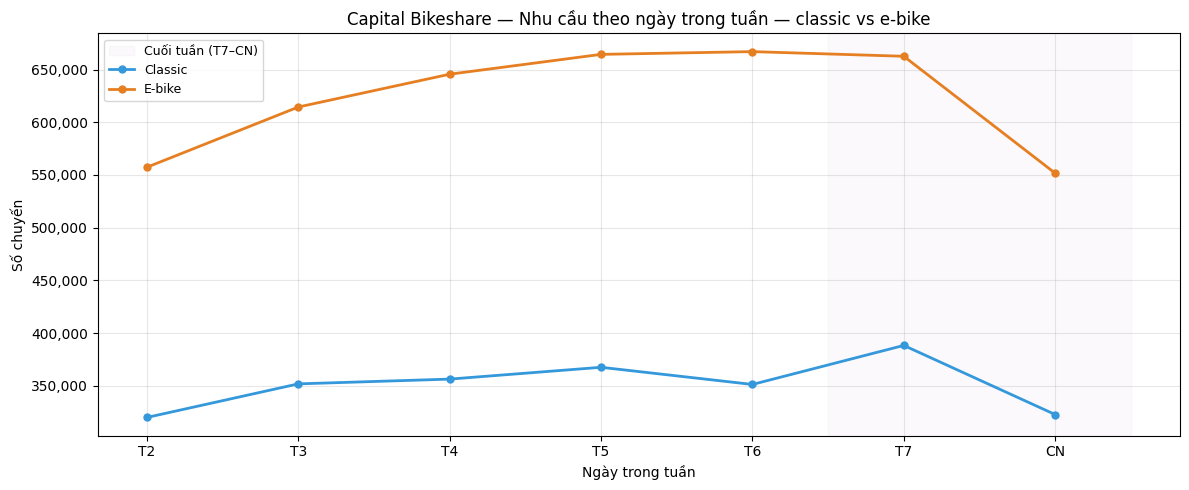

In [202]:
plot_weekday_demand_by_bike_type(DATA_PATH, SYSTEM_NAME)


### 14. Member vs casual — số chuyến

+ Line chart 7 ngày theo nhóm người dùng
+ Casual thường tăng mạnh cuối tuần


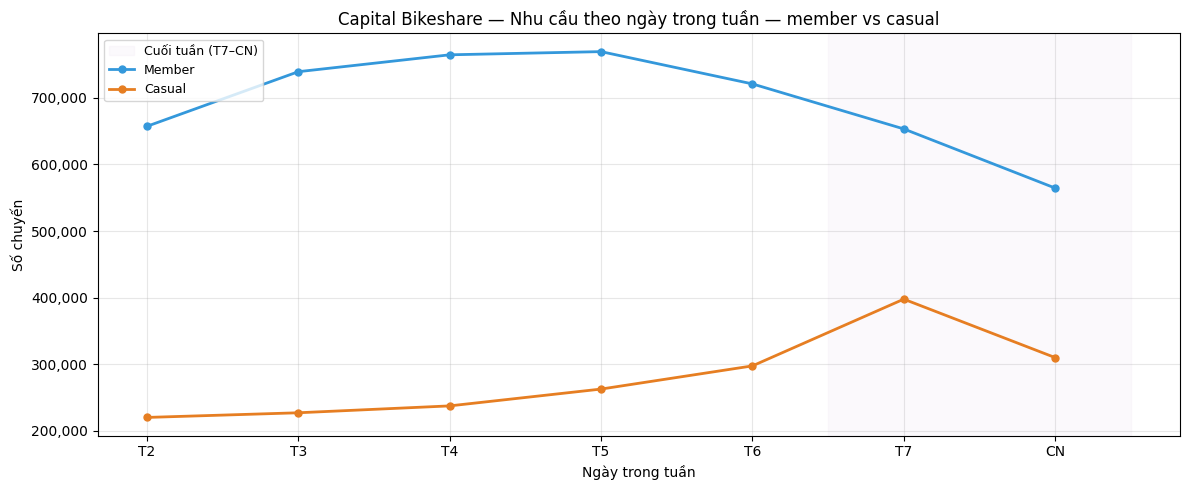

In [203]:
plot_weekday_demand_by_user(DATA_PATH, SYSTEM_NAME)


## Khối D · Heatmap giờ × ngày — toàn kỳ

+ Gộp cả 13 tháng thành một ma trận 7×24
+ Màu đậm = nhiều chuyến; mỗi panel scale riêng


### 15. Member | casual

+ Trục X: giờ (0–23); trục Y: ngày (T2–CN)
+ Hai panel cạnh nhau — so sánh pattern tuần


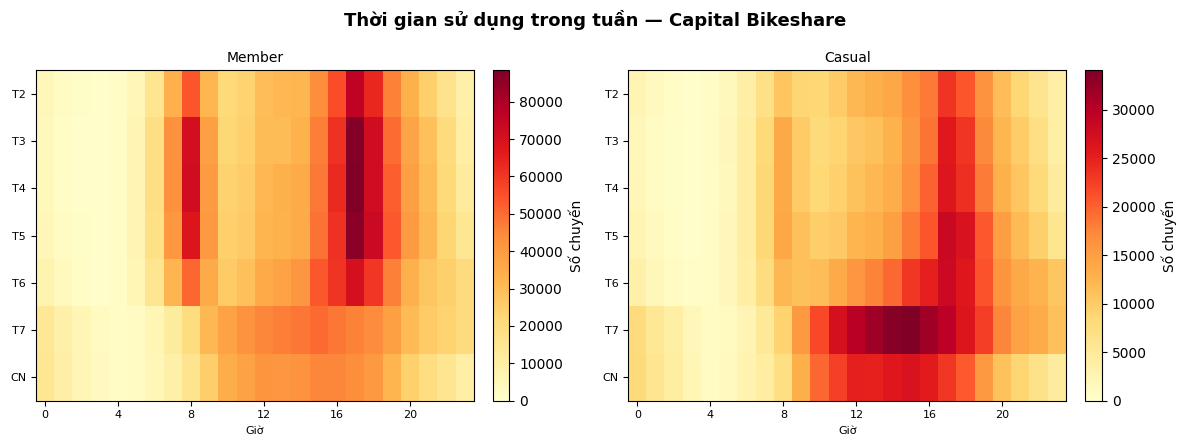

In [204]:
plot_weekly_usage_heatmap(DATA_PATH, SYSTEM_NAME)


### 16. Classic | e-bike

+ Cùng form với phần 15
+ E-bike thường đỉnh rõ hơn giờ cao điểm


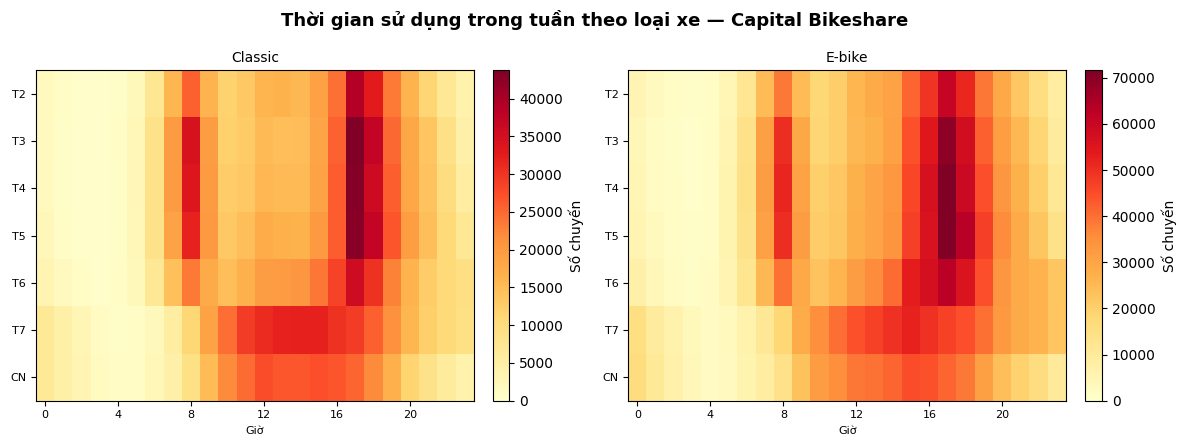

In [205]:
plot_weekly_usage_heatmap_by_bike_type(DATA_PATH, SYSTEM_NAME)


### 17. Lưới 2×2 (người dùng × loại xe)

+ Bốn ô: member×classic, member×e-bike, casual×classic, casual×e-bike
+ Phát hiện tương tác giữa loại xe và nhóm người dùng


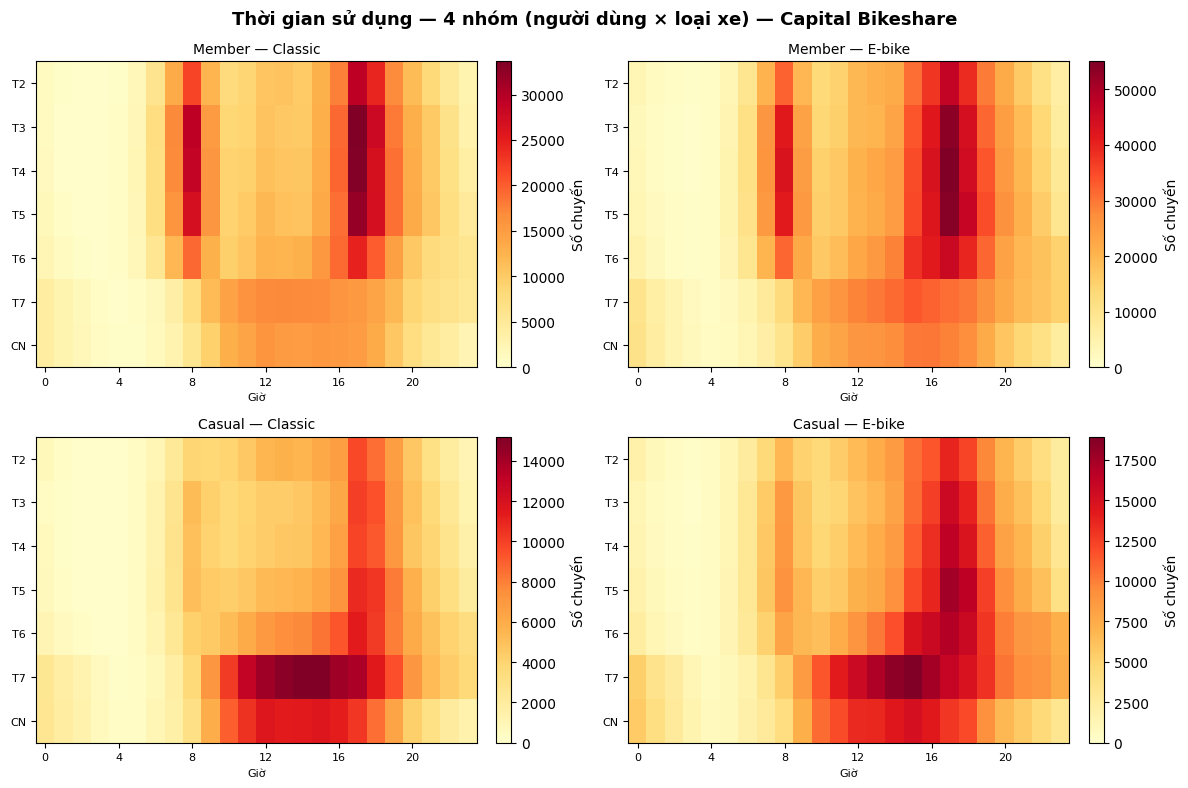

In [206]:
plot_weekly_usage_heatmap_user_bike_grid(DATA_PATH, SYSTEM_NAME)


## Khối E · Heatmap giờ × ngày — theo tháng

+ 13 hàng (mỗi tháng một hàng), mỗi hàng 2 cột
+ Theo dõi mùa vụ và thay đổi pattern theo tháng


### 18. Member | casual

+ 13 hàng × 2 cột (member / casual)
+ So sánh mùa vụ giữa hai nhóm người dùng


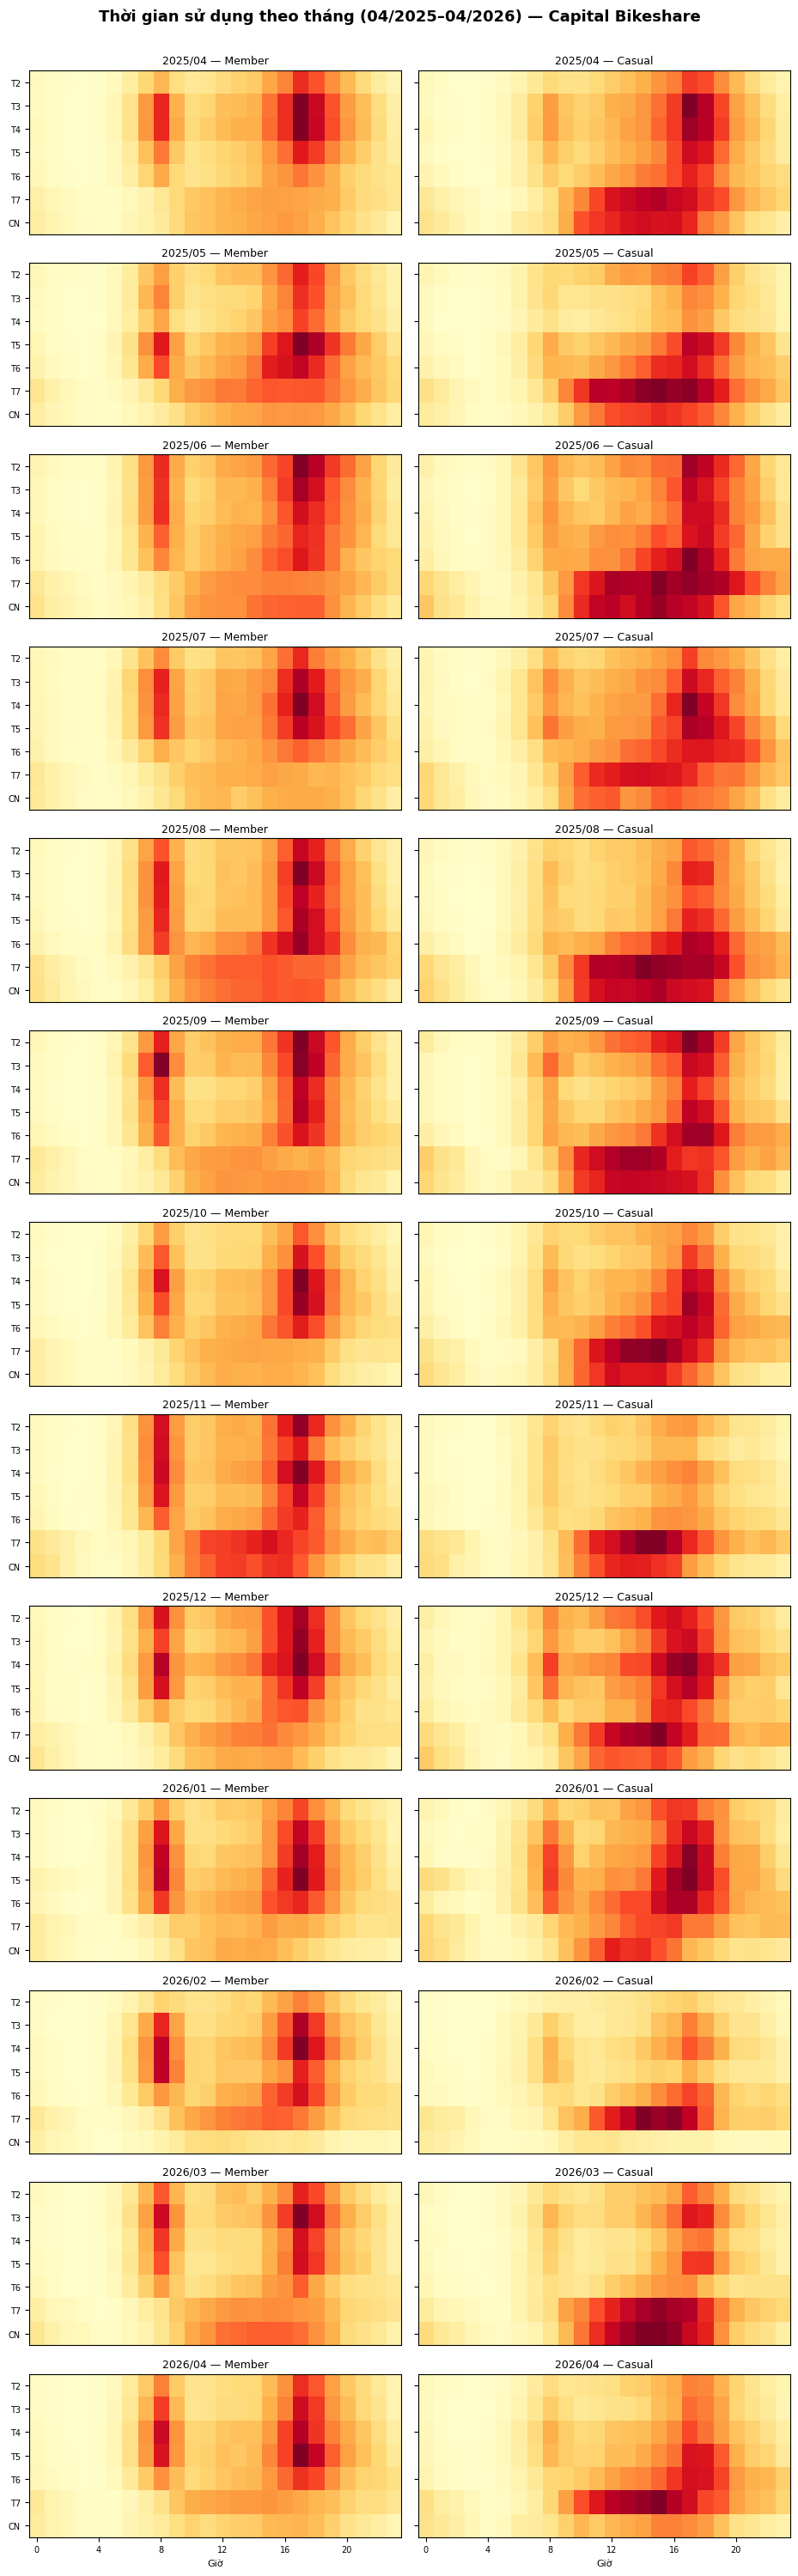

In [207]:
plot_monthly_usage_heatmaps(DATA_PATH, SYSTEM_NAME)


### 19. Classic | e-bike

+ 13 hàng × 2 cột — cùng form với phần 16
+ Thấy e-bike tăng/giảm theo mùa khác classic


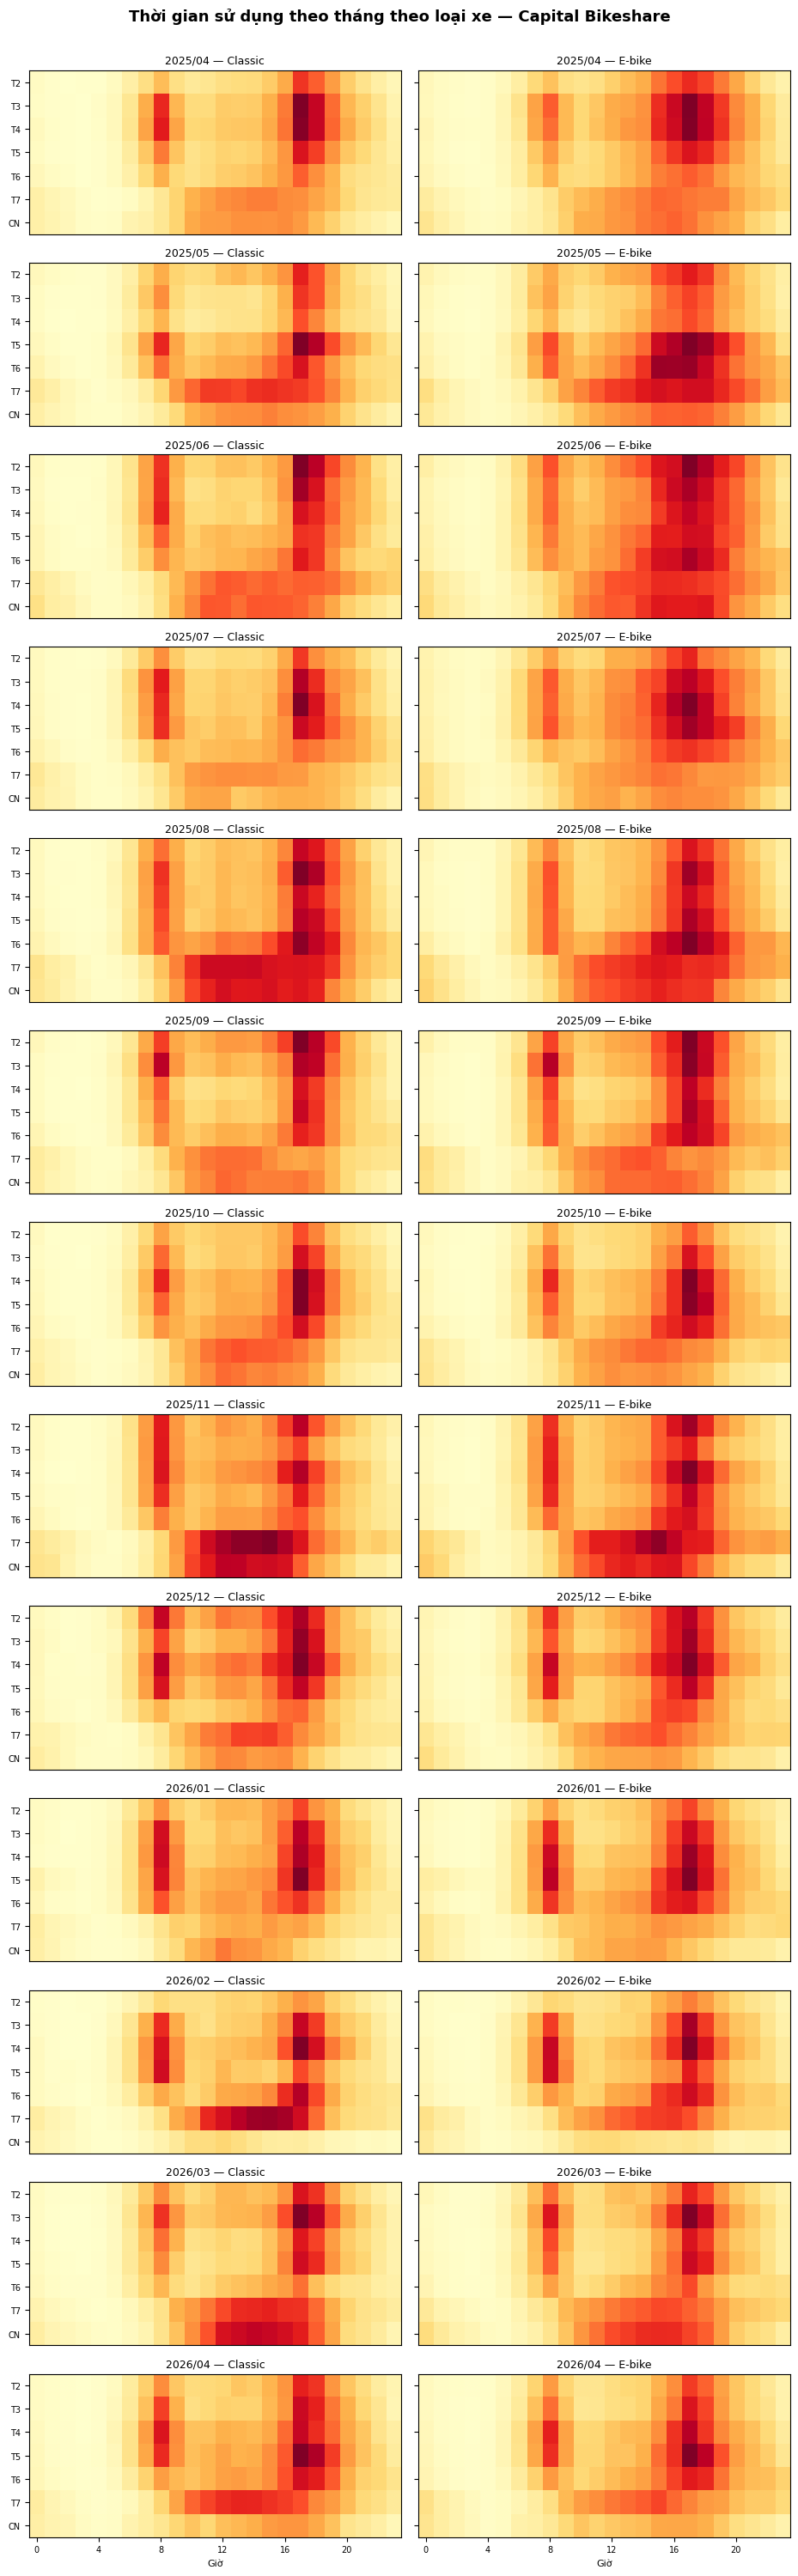

In [208]:
plot_monthly_usage_heatmaps_by_bike_type(DATA_PATH, SYSTEM_NAME)


### 20. Member — classic | e-bike

+ 13 hàng × 2 cột — chỉ nhóm member
+ Member đi classic nhiều hơn e-bike ở hầu hết khung giờ


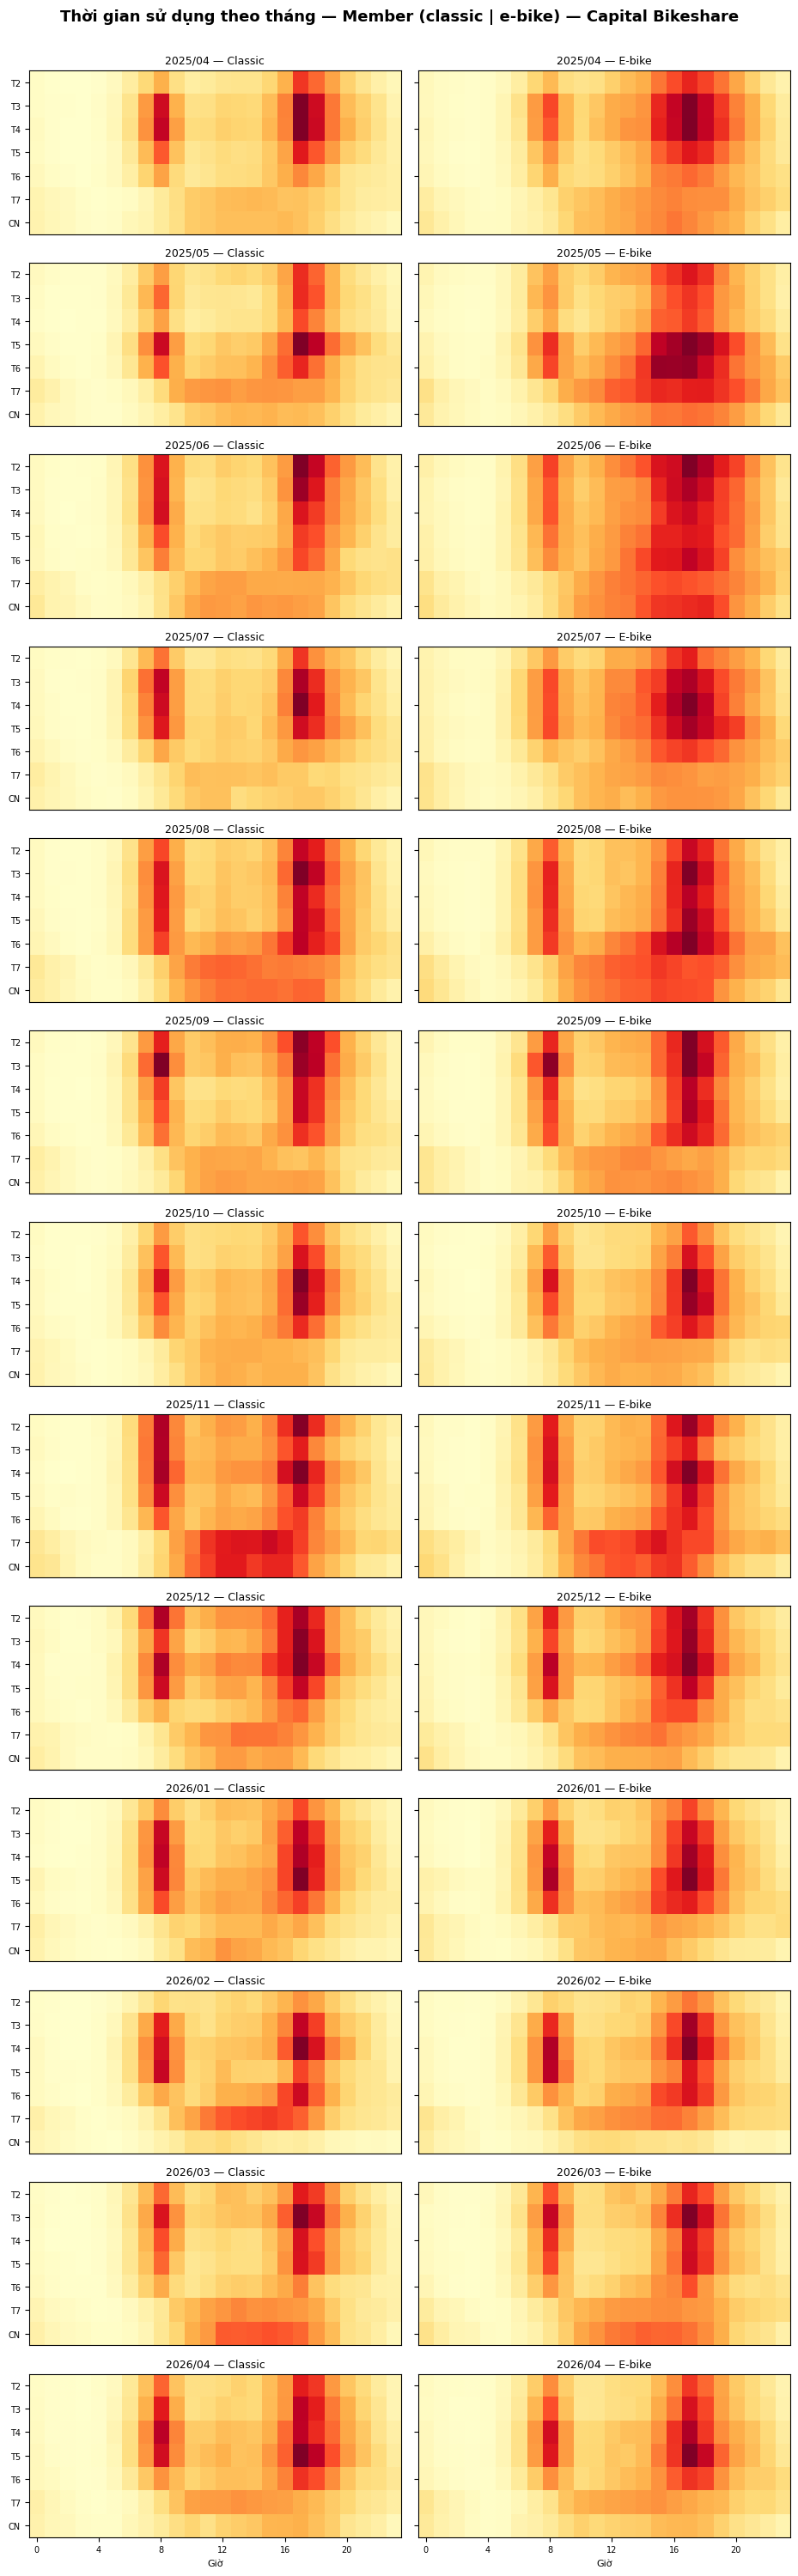

In [209]:
plot_monthly_usage_heatmaps_member_by_bike(DATA_PATH, SYSTEM_NAME)


### 21. Casual — classic | e-bike

+ 13 hàng × 2 cột — chỉ nhóm casual
+ Casual ưa e-bike hơn, đặc biệt cuối tuần và ban đêm


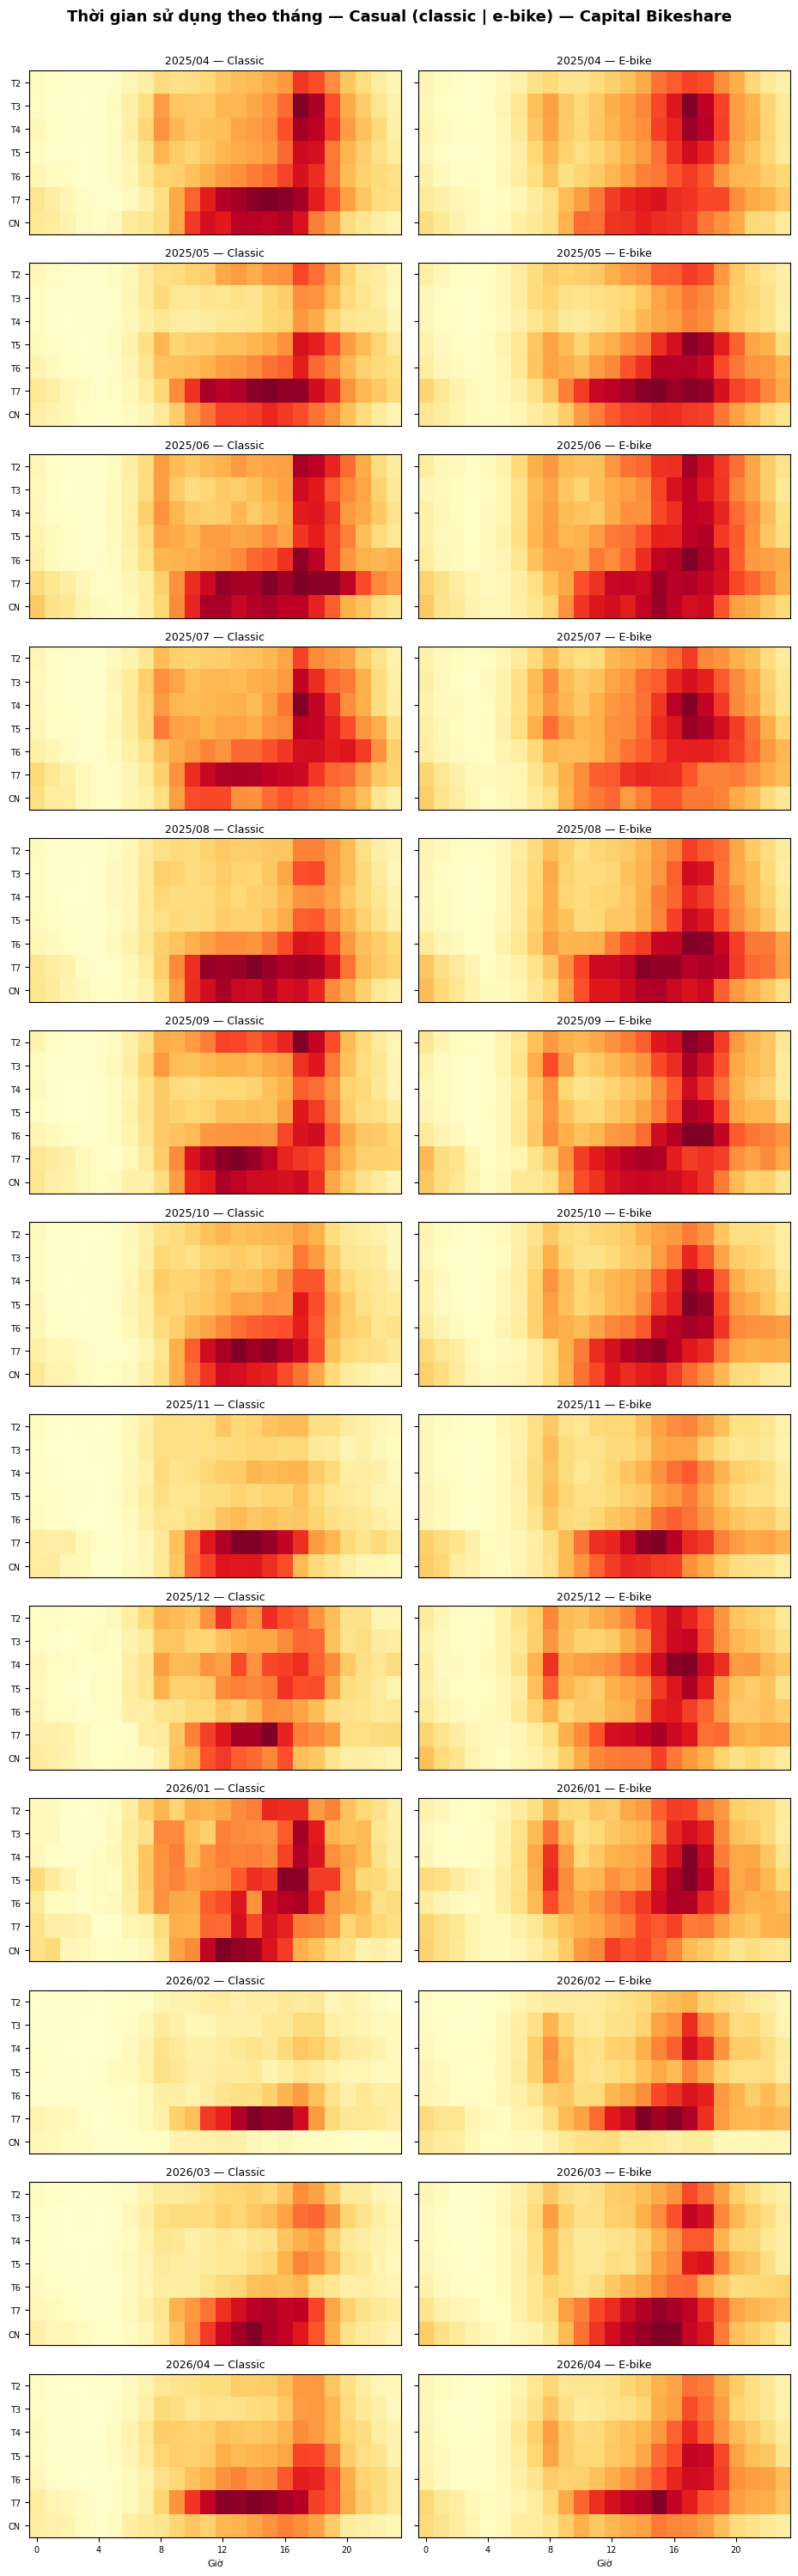

In [210]:
plot_monthly_usage_heatmaps_casual_by_bike(DATA_PATH, SYSTEM_NAME)


## Khối F · Bản đồ trạm

+ Bản đồ tương tác OpenStreetMap (folium)
+ Kích thước chấm ∝ số chuyến bắt đầu tại trạm


### Bản đồ trạm — số chuyến bắt đầu

+ Nền OpenStreetMap; zoom/pan tương tác
+ Gom trạm theo `station_id` hoặc tọa độ làm tròn
+ ~20% e-bike đỗ rack — chấm gom theo tọa độ làm tròn khi thiếu `station_id`
+ Kích thước chấm ∝ số chuyến; cluster khi zoom xa


In [211]:
plot_station_map(DATA_PATH, SYSTEM_NAME)
